In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
from sklearn.datasets import load_iris
df = load_iris()


In [29]:
X = pd.DataFrame(df.data)
y = df.target

In [30]:
X

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=10)

In [33]:
from sklearn.tree import DecisionTreeClassifier
tree_class = DecisionTreeClassifier()
tree_class.fit(X_train,y_train)

DecisionTreeClassifier()

[Text(0.3076923076923077, 0.9285714285714286, 'x[3] <= 0.8\ngini = 0.665\nsamples = 120\nvalue = [40, 37, 43]'),
 Text(0.23076923076923078, 0.7857142857142857, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.2692307692307693, 0.8571428571428572, 'True  '),
 Text(0.38461538461538464, 0.7857142857142857, 'x[2] <= 4.75\ngini = 0.497\nsamples = 80\nvalue = [0, 37, 43]'),
 Text(0.34615384615384615, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'x[3] <= 1.65\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6153846153846154, 0.6428571428571429, 'x[3] <= 1.75\ngini = 0.159\nsamples = 46\nvalue = [0, 4, 42]'),
 Text(0.38461538461538464, 0.5, 'x[1] <= 2.65\ngini = 0.49\nsamples = 7\nvalue = [0, 3, 4]'),
 Text(0.3076923076923077, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [0, 

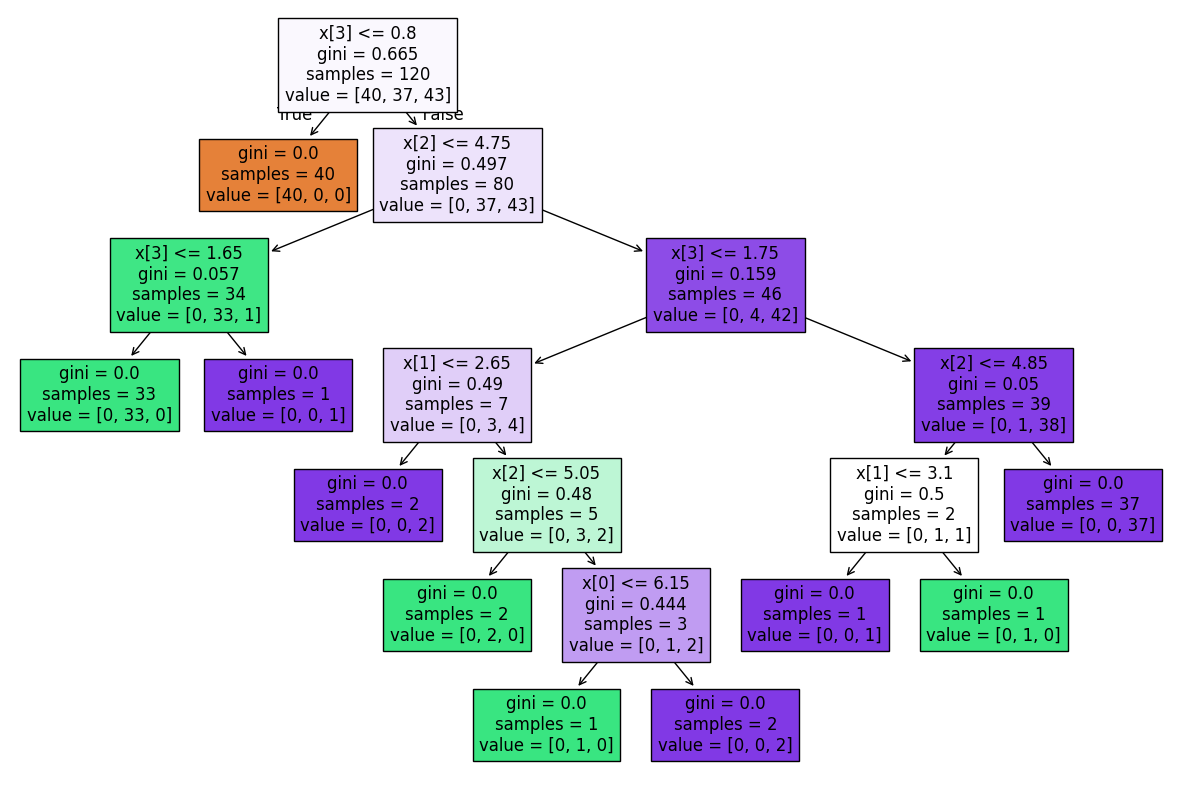

In [ ]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(tree_class,filled=True)

[Text(0.4, 0.8333333333333334, 'x[2] <= 2.45\ngini = 0.665\nsamples = 120\nvalue = [40, 37, 43]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= 4.75\ngini = 0.497\nsamples = 80\nvalue = [0, 37, 43]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.057\nsamples = 34\nvalue = [0, 33, 1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.159\nsamples = 46\nvalue = [0, 4, 42]')]

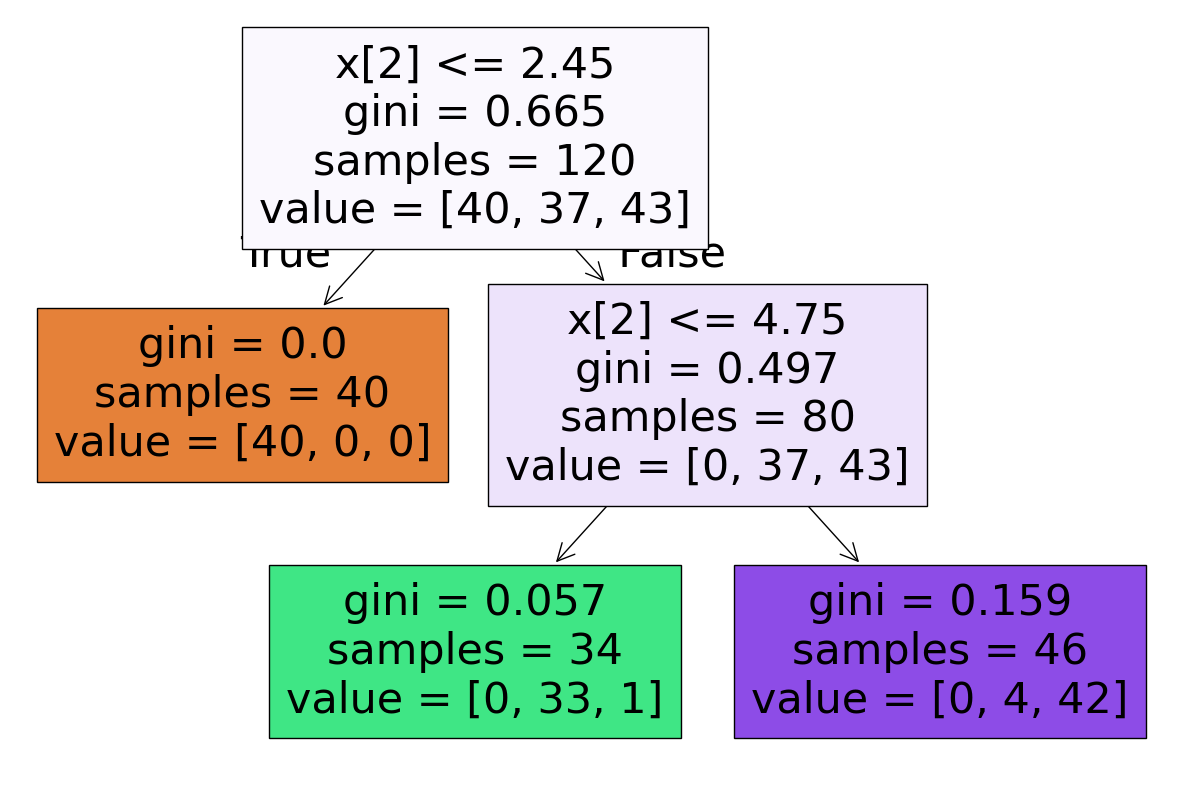

In [35]:
from sklearn.tree import DecisionTreeClassifier
tree_class = DecisionTreeClassifier(max_depth=2)
tree_class.fit(X_train,y_train)
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(tree_class,filled=True)

In [36]:
y_pred = tree_class.predict(X_test)

In [38]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[10  0  0]
 [ 0 11  2]
 [ 0  0  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.85      0.92        13
           2       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.95      0.93        30
weighted avg       0.95      0.93      0.93        30



In [39]:
from sklearn.datasets import load_diabetes
df = load_diabetes()
X = pd.DataFrame(df.data)
y= df.target

In [44]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.3,random_state=10)

<Axes: >

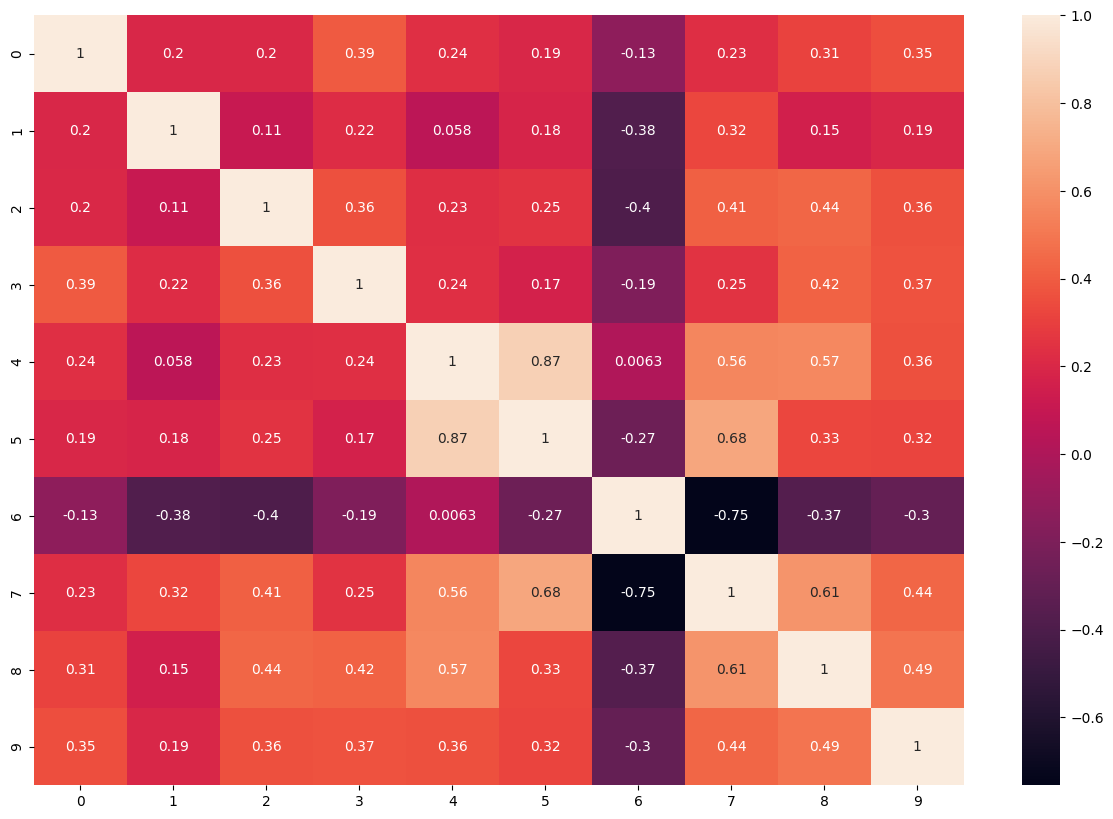

In [47]:
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(),annot=True)

In [48]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()

In [52]:
from sklearn.model_selection import GridSearchCV
grid= GridSearchCV(estimator=model,param_grid={
    "criterion": ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    "splitter": ['best', 'random'],
     "max_depth" :[2,3,4,5,6,7,8,9],
     "max_features":['auto', 'sqrt', 'log2']
},cv=5,scoring="neg_mean_squared_error")

In [53]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [2, 3, 4, 5, 6, 7, 8, 9],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [54]:
grid.best_params_

{'criterion': 'squared_error',
 'max_depth': 3,
 'max_features': 'log2',
 'splitter': 'best'}

In [55]:
y_pred = grid.predict(X_test)


In [57]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,r2_score
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(root_mean_squared_error(y_test,y_pred))

0.400456828096166
47.72142248447315
3793.711999078978
61.59311649104125


[Text(0.5, 0.875, 'x[2] <= 0.016\nsquared_error = 5757.456\nsamples = 309\nvalue = 152.738'),
 Text(0.25, 0.625, 'x[8] <= -0.004\nsquared_error = 3732.377\nsamples = 205\nvalue = 125.498'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[3] <= 0.118\nsquared_error = 2200.983\nsamples = 120\nvalue = 101.508'),
 Text(0.0625, 0.125, 'squared_error = 2108.399\nsamples = 119\nvalue = 100.546'),
 Text(0.1875, 0.125, 'squared_error = 0.0\nsamples = 1\nvalue = 216.0'),
 Text(0.375, 0.375, 'x[3] <= -0.045\nsquared_error = 3934.914\nsamples = 85\nvalue = 159.365'),
 Text(0.3125, 0.125, 'squared_error = 578.149\nsamples = 11\nvalue = 110.818'),
 Text(0.4375, 0.125, 'squared_error = 4031.487\nsamples = 74\nvalue = 166.581'),
 Text(0.75, 0.625, 'x[3] <= 0.024\nsquared_error = 5403.399\nsamples = 104\nvalue = 206.433'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[8] <= 0.024\nsquared_error = 5492.476\nsamples = 58\nvalue = 178.724'),
 Text(0.5625, 0.125, 'squared_error = 2661.624\nsam

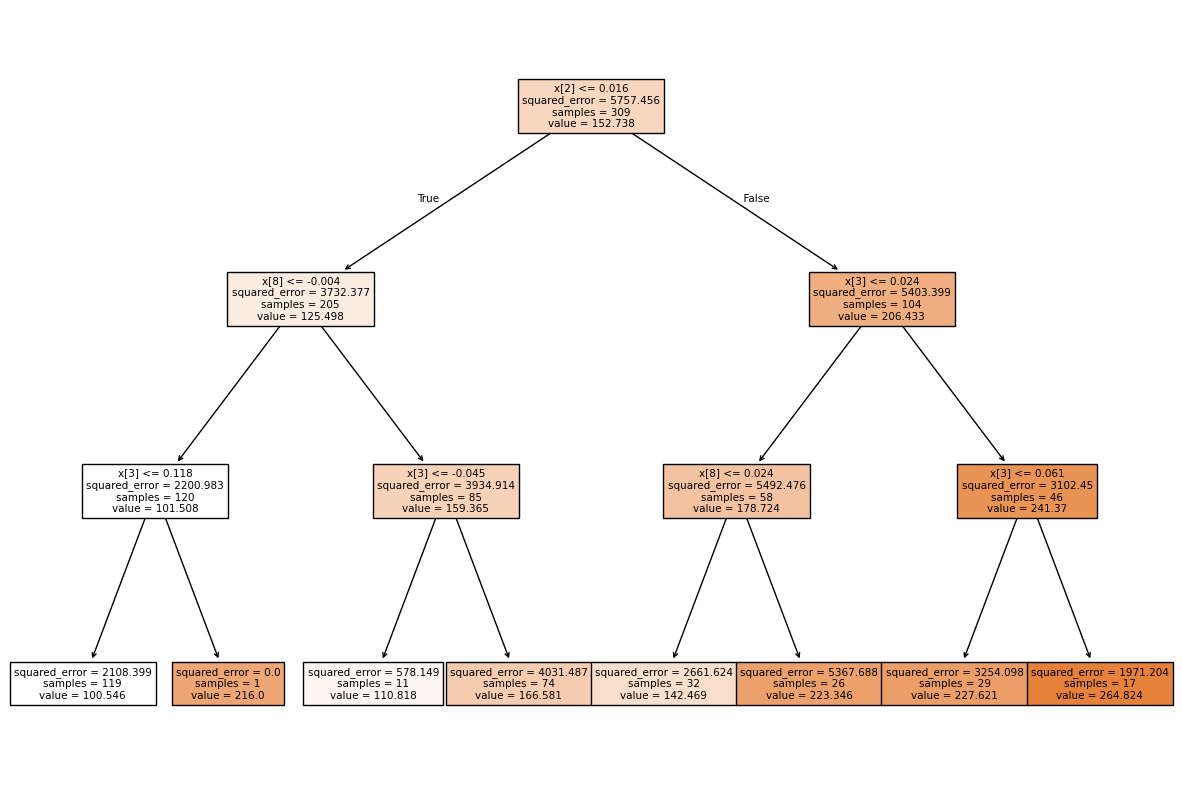

In [60]:
plt.figure(figsize=(15,10))
tree.plot_tree(grid.best_estimator_,filled=True)